In [1]:
!pip install networkx matplotlib pandas cdlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
os.listdir()

['.android',
 '.angular-config.json',
 '.cache',
 '.cagent',
 '.config',
 '.docker',
 '.eclipse',
 '.emulator_console_auth_token',
 '.erlang.cookie',
 '.gitconfig',
 '.gradle',
 '.idlerc',
 '.ipynb_checkpoints',
 '.ipython',
 '.keras',
 '.m2',
 '.matplotlib',
 '.nbi',
 '.node_repl_history',
 '.oracle_jre_usage',
 '.p2',
 '.scenebuilder',
 '.skiko',
 '.streamlit',
 '.th-client',
 '.VirtualBox',
 '.vscode',
 'AndroidStudioProjects',
 'AndroidStudioProjects (2).zip',
 'AndroidStudioProjects.zip',
 'AppData',
 'Application Data',
 'ARS_Facebook_Project.ipynb',
 'Contacts',
 'Cookies',
 'db.sqlite3',
 'Documents',
 'Downloads',
 'eclipse',
 'eclipse-workspace',
 'edb_pgagent_pg15.exe',
 'env',
 'facebook_combined.txt',
 'fake-news-detection',
 'fake_news_project',
 'fake_true_news_app',
 'Favorites',
 'frontend',
 'gestion-rh',
 'hr-dashboard-app',
 'hr_management',
 'hr_management (2).zip',
 'hr_management - Copie',
 'hr_management.zip',
 'Links',
 'llama-app',
 'Local Settings',
 'Menu Dé

In [3]:
import networkx as nx

G = nx.read_edgelist("facebook_combined.txt", nodetype=int)

print("Nombre de nœuds :", G.number_of_nodes())
print("Nombre de liens :", G.number_of_edges())

Nombre de nœuds : 4039
Nombre de liens : 88234


In [4]:
print("Densité :", nx.density(G))
print("Connexe :", nx.is_connected(G))

Densité : 0.010819963503439287
Connexe : True


In [5]:
%matplotlib inline

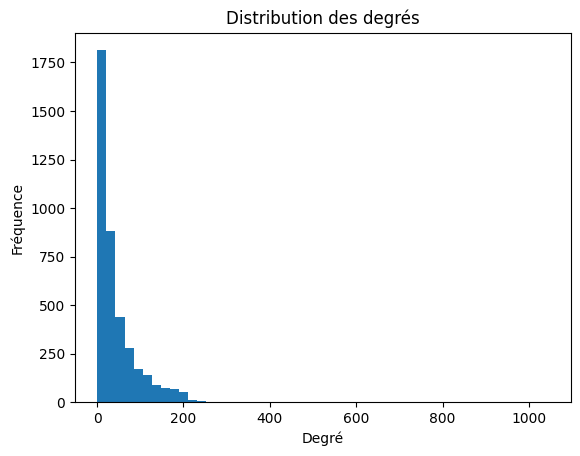

In [6]:
import matplotlib.pyplot as plt

degrees = [d for _, d in G.degree()]

plt.hist(degrees, bins=50)
plt.title("Distribution des degrés")
plt.xlabel("Degré")
plt.ylabel("Fréquence")
plt.show()

In [7]:
components = list(nx.connected_components(G))

print("Nombre de composants :", len(components))

sizes = [len(c) for c in components]
print("Taille du plus grand composant :", max(sizes))
print("Taille du plus petit composant :", min(sizes))

Nombre de composants : 1
Taille du plus grand composant : 4039
Taille du plus petit composant : 4039


In [8]:
largest_cc = max(nx.connected_components(G), key=len)
G_main = G.subgraph(largest_cc)

print("Nombre de nœuds (composant principal) :", G_main.number_of_nodes())

Nombre de nœuds (composant principal) : 4039


In [ ]:
G_small = G.subgraph(list(G.nodes())[:500])

clustering = nx.average_clustering(G_small)

print("Clustering (approximation) :", clustering)

In [10]:
G_small = G.subgraph(list(G.nodes())[:100])

print("Clustering :", nx.average_clustering(G_small))

Clustering : 0.596215689907419


In [11]:
print("Transitivité :", nx.transitivity(G))

Transitivité : 0.5191742775433075


In [12]:
G_small = G.subgraph(list(G.nodes())[:100])
print("Clustering (approx) :", nx.average_clustering(G_small))

Clustering (approx) : 0.596215689907419


In [14]:
G_small = G.subgraph(list(G.nodes())[:300])
print("Clustering (approx) :", nx.average_clustering(G_small))

Clustering (approx) : 0.667809316734457


In [15]:
G_small = G.subgraph(list(G.nodes())[:500])
print("Clustering (approx) :", nx.average_clustering(G_small))

Clustering (approx) : 0.6506405789776873


In [16]:
G_small = G.subgraph(list(G.nodes())[:1000])
print("Clustering (approx) :", nx.average_clustering(G_small))

Clustering (approx) : 0.6081747230750039


In [17]:
G_small = G.subgraph(list(G.nodes())[:2000])
print("Clustering (approx) :", nx.average_clustering(G_small))

Clustering (approx) : 0.6158592755935848


In [18]:
print("Coefficient de clustering moyen :", nx.average_clustering(G))
print("Densité :", nx.density(G))

Coefficient de clustering moyen : 0.6055467186200876
Densité : 0.010819963503439287


In [19]:
degree_centrality = nx.degree_centrality(G)

top_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:10]

top_nodes

[(107, 0.258791480931154),
 (1684, 0.1961367013372957),
 (1912, 0.18697374938088163),
 (3437, 0.13546310054482416),
 (0, 0.08593363051015354),
 (2543, 0.07280832095096582),
 (2347, 0.07206537890044576),
 (1888, 0.0629024269440317),
 (1800, 0.06067360079247152),
 (1663, 0.058197127290737984)]

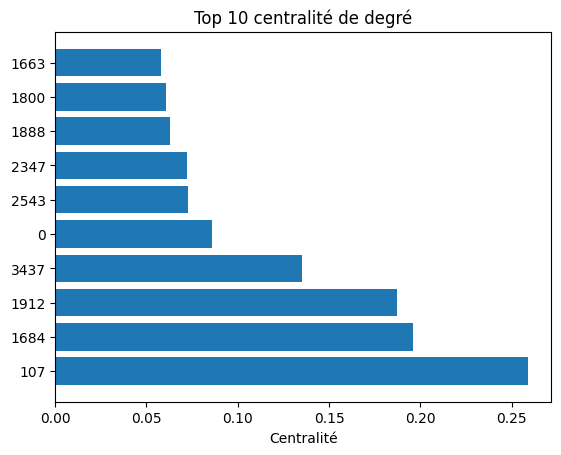

In [20]:
nodes = [str(n) for n, _ in top_nodes]
values = [v for _, v in top_nodes]

plt.barh(nodes, values)
plt.title("Top 10 centralité de degré")
plt.xlabel("Centralité")
plt.show()

In [21]:
from cdlib import algorithms

Note: to be able to use all crisp methods, you need to install some additional packages:  {'bayanpy', 'graph_tool', 'infomap', 'wurlitzer', 'leidenalg'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'leidenalg', 'wurlitzer'}


In [25]:
from cdlib import algorithms

com_louvain = algorithms.louvain(G)
com_greedy = algorithms.greedy_modularity(G)

In [26]:
louvain = algorithms.louvain(G)

print("Louvain - Nombre de communautés :", len(louvain.communities))

Louvain - Nombre de communautés : 16


In [27]:
label = algorithms.label_propagation(G)

print("Label Propagation - Nombre de communautés :", len(label.communities))

Label Propagation - Nombre de communautés : 44


In [28]:
infomap = algorithms.infomap(G)

print("Infomap - Nombre de communautés :", len(infomap.communities))

Infomap - Nombre de communautés : 75


In [29]:
from cdlib import evaluation

print("Modularité Louvain :", evaluation.newman_girvan_modularity(G, louvain))
print("Modularité Label :", evaluation.newman_girvan_modularity(G, label))
print("Modularité Infomap :", evaluation.newman_girvan_modularity(G, infomap))

Modularité Louvain : FitnessResult(min=None, max=None, score=0.8349652587713134, std=None)
Modularité Label : FitnessResult(min=None, max=None, score=0.7368407345348216, std=None)
Modularité Infomap : FitnessResult(min=None, max=None, score=0.13669192209164402, std=None)


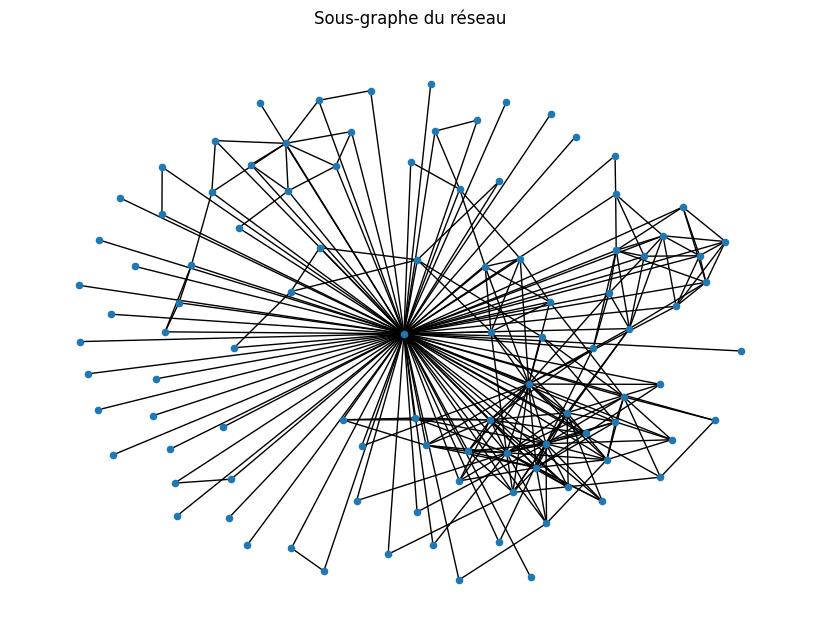

In [30]:
plt.figure(figsize=(8,6))

subgraph = G.subgraph(list(G.nodes())[:100])

nx.draw(subgraph, node_size=20)

plt.title("Sous-graphe du réseau")
plt.show()

In [33]:
# Conclusion

#- Le réseau Facebook présente un grand composant connecté
#- Il possède un faible diamètre (effet petit monde)
#- Le clustering est élevé (présence de communautés)
#- Certains nœuds sont très influents
#- Les algorithmes de détection de communautés confirment la structure modulaire du réseau

In [34]:
list(G.edges())[:10]

[(0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (0, 5),
 (0, 6),
 (0, 7),
 (0, 8),
 (0, 9),
 (0, 10)]

In [37]:
print("Nombre de composantes :", nx.number_connected_components(G))

largest_cc = max(nx.connected_components(G), key=len)
G_cc = G.subgraph(largest_cc)

print("Taille plus grande composante :", len(G_cc.nodes()))

Nombre de composantes : 1
Taille plus grande composante : 4039


In [39]:
import os
os.getcwd()

'C:\\Users\\bsmar'